In [ ]:
import pandas as pd
import os
from pathlib import Path

def csv_to_yolo_txt(csv_path, output_dir):
    """
    Convert CSV with ROI coordinates to YOLO format text files

    ROI format (x1,y1,x2,y2) -> YOLO format (class x_center y_center width height)
    All coordinates normalized to 0-1
    """

    # Load CSV
    df = pd.read_csv(csv_path)

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Group by image filename (Path column)
    grouped = df.groupby('Path')

    print(f"📁 Processing {len(grouped)} images...")

    for image_path, group in grouped:
        # Get the base filename without extension
        base_name = Path(image_path).stem
        txt_filename = f"{base_name}.txt"
        txt_path = os.path.join(output_dir, txt_filename)

        # Write annotations to text file
        with open(txt_path, 'w') as f:
            for _, row in group.iterrows():
                # Extract ROI coordinates
                x1 = row['Roi.X1']
                y1 = row['Roi.Y1']
                x2 = row['Roi.X2']
                y2 = row['Roi.Y2']
                class_id = int(row['ClassId'])

                # Get actual image dimensions from Width and Height columns
                img_width = row['Width']
                img_height = row['Height']

                # Convert ROI to YOLO format
                # Calculate center coordinates
                x_center = (x1 + x2) / 2.0
                y_center = (y1 + y2) / 2.0

                # Calculate width and height
                width = x2 - x1
                height = y2 - y1

                # Normalize to 0-1 range
                x_center_norm = x_center / img_width
                y_center_norm = y_center / img_height
                width_norm = width / img_width
                height_norm = height / img_height

                # YOLO format: class_id x_center y_center width height
                line = f"{class_id} {x_center_norm:.6f} {y_center_norm:.6f} {width_norm:.6f} {height_norm:.6f}\n"
                f.write(line)

    print(f"✅ Created {len(grouped)} annotation files in '{output_dir}'")
    return len(grouped)


# ==================== PROCESS TRAIN AND TEST DATA ====================

# TRAIN dataset
train_csv_path = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/Train.csv'
train_output_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/train'

print("🚀 Converting TRAIN annotations...")
num_train = csv_to_yolo_txt(train_csv_path, train_output_dir)
print(f"✅ TRAIN: Created {num_train} label files\n")

# TEST dataset
test_csv_path = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/Test.csv'
test_output_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test'

print("🚀 Converting TEST annotations...")
num_test = csv_to_yolo_txt(test_csv_path, test_output_dir)
print(f"✅ TEST: Created {num_test} label files\n")

print("🎉 Conversion complete!")
print(f"\n📂 Your folder structure:")
print(f"   Train labels: {train_output_dir}")
print(f"   Test labels:  {test_output_dir}")
print("\n💡 Make sure your images folder structure matches:")
print("""
   /content/drive/MyDrive/Major Project/43_Classes_Yolo/
   ├── images/
   │   ├── train/
   │   │   └── (your train images)
   │   └── test/
   │       └── (your test images)
   └── YOLO_txtfile/
       ├── train/
       │   └── (generated .txt files)
       └── test/
           └── (generated .txt files)
""")

🚀 Converting TRAIN annotations...
📁 Processing 39209 images...
✅ Created 39209 annotation files in '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/train'
✅ TRAIN: Created 39209 label files

🚀 Converting TEST annotations...
📁 Processing 12630 images...
✅ Created 12630 annotation files in '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test'
✅ TEST: Created 12630 label files

🎉 Conversion complete!

📂 Your folder structure:
   Train labels: /content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/train
   Test labels:  /content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test

💡 Make sure your images folder structure matches:

   /content/drive/MyDrive/Major Project/43_Classes_Yolo/
   ├── images/
   │   ├── train/
   │   │   └── (your train images)
   │   └── test/
   │       └── (your test images)
   └── YOLO_txtfile/
       ├── train/
       │   └── (generated .txt files)
       └── test/
           └── (generated .txt files)

In [ ]:
ls /content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/train

ls: cannot access '/content/drive/MyDrive/Major': No such file or directory
ls: cannot access 'Project/43_Classes_Yolo/YOLO_txtfile/train': No such file or directory


In [ ]:
TRAIN_LABELS = "/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/train/00000"
TEST_LABELS  = "/content/drive/MyDrive/Major Project/43_Classes_Yolo/Images/Test"

!ls "$TRAIN_LABELS" | wc -l
!ls "$TEST_LABELS" | wc -l


^C
12631


(np.float64(-0.5), np.float64(52.5), np.float64(53.5), np.float64(-0.5))

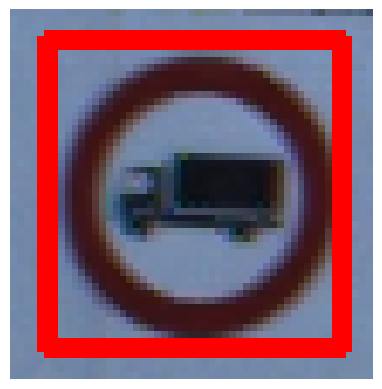

In [ ]:
import cv2
import matplotlib.pyplot as plt


img_path = "/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/00000.png"
label_path = "/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test/00000.txt"


img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img.shape


with open(label_path) as f:
    for line in f:
        c, x, y, bw, bh = map(float, line.split())
        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)


plt.imshow(img)
plt.axis("off")


In [ ]:
import os
import shutil
from pathlib import Path

def filter_annotations_by_class(input_labels_dir, output_labels_dir, input_images_dir=None,
                                output_images_dir=None, target_classes=None):
    """
    Filter YOLO annotations to keep only specific classes
    Optionally also copy corresponding images

    Parameters:
    - input_labels_dir: Path to original label files
    - output_labels_dir: Path where filtered labels will be saved
    - input_images_dir: Path to original images (optional)
    - output_images_dir: Path where corresponding images will be copied (optional)
    - target_classes: List of class IDs to keep
    """

    if target_classes is None:
        target_classes = [11, 19, 20, 21, 22, 23, 24, 25, 26, 28, 40]

    # Create output directories
    os.makedirs(output_labels_dir, exist_ok=True)
    if output_images_dir:
        os.makedirs(output_images_dir, exist_ok=True)

    # Get all txt files
    label_files = [f for f in os.listdir(input_labels_dir) if f.endswith('.txt')]

    print(f"📁 Found {len(label_files)} label files")
    print(f"🎯 Target classes: {target_classes}\n")

    files_with_target_classes = 0
    total_annotations_kept = 0
    total_annotations_removed = 0

    for label_file in label_files:
        input_path = os.path.join(input_labels_dir, label_file)
        output_path = os.path.join(output_labels_dir, label_file)

        # Read annotations
        with open(input_path, 'r') as f:
            lines = f.readlines()

        # Filter lines - keep only target classes
        filtered_lines = []
        for line in lines:
            if line.strip():  # Skip empty lines
                class_id = int(line.split()[0])
                if class_id in target_classes:
                    filtered_lines.append(line)
                    total_annotations_kept += 1
                else:
                    total_annotations_removed += 1

        # Only save if file has target class annotations
        if filtered_lines:
            files_with_target_classes += 1

            # Write filtered annotations
            with open(output_path, 'w') as f:
                f.writelines(filtered_lines)

            # Copy corresponding image if paths provided
            if input_images_dir and output_images_dir:
                base_name = Path(label_file).stem

                # Try different image extensions
                for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG']:
                    image_file = base_name + ext
                    input_image_path = os.path.join(input_images_dir, image_file)

                    if os.path.exists(input_image_path):
                        output_image_path = os.path.join(output_images_dir, image_file)
                        shutil.copy2(input_image_path, output_image_path)
                        break

    print(f"✅ Files with target classes: {files_with_target_classes} / {len(label_files)}")
    print(f"✅ Annotations kept: {total_annotations_kept}")
    print(f"❌ Annotations removed: {total_annotations_removed}")
    print(f"\n📂 Filtered labels saved to: {output_labels_dir}")
    if output_images_dir:
        print(f"📂 Corresponding images saved to: {output_images_dir}")

    return files_with_target_classes


# ==================== OPTION 1: FILTER ONLY LABELS ====================
# Use this if you only want to filter txt files

input_labels_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test'
output_labels_dir = '/content/drive/MyDrive/Major Project/split_dataset/test_filtered'

target_classes = [11, 19, 20, 21, 22, 23, 24, 25, 26, 28, 40]

print("🚀 Filtering test annotations for specific classes...\n")

num_files = filter_annotations_by_class(
    input_labels_dir=input_labels_dir,
    output_labels_dir=output_labels_dir,
    target_classes=target_classes
)

print("\n🎉 Filtering complete!")


# ==================== OPTION 2: FILTER LABELS + COPY IMAGES ====================
# Uncomment this section if you also want to copy corresponding images

"""
input_labels_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test'
output_labels_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test_filtered'

input_images_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/images/test'
output_images_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/images/test_filtered'

target_classes = [11, 19, 20, 21, 22, 23, 24, 25, 26, 28, 40]

print("🚀 Filtering test annotations and copying corresponding images...\n")

num_files = filter_annotations_by_class(
    input_labels_dir=input_labels_dir,
    output_labels_dir=output_labels_dir,
    input_images_dir=input_images_dir,
    output_images_dir=output_images_dir,
    target_classes=target_classes
)

print("\n🎉 Filtering complete!")
print("✅ Both filtered labels and images are ready!")
"""

🚀 Filtering test annotations for specific classes...

📁 Found 12630 label files
🎯 Target classes: [11, 19, 20, 21, 22, 23, 24, 25, 26, 28, 40]

✅ Files with target classes: 1920 / 12630
✅ Annotations kept: 1920
❌ Annotations removed: 10710

📂 Filtered labels saved to: /content/drive/MyDrive/Major Project/split_dataset/test_filtered

🎉 Filtering complete!


'\ninput_labels_dir = \'/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test\'\noutput_labels_dir = \'/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test_filtered\'\n\ninput_images_dir = \'/content/drive/MyDrive/Major Project/43_Classes_Yolo/images/test\'\noutput_images_dir = \'/content/drive/MyDrive/Major Project/43_Classes_Yolo/images/test_filtered\'\n\ntarget_classes = [11, 19, 20, 21, 22, 23, 24, 25, 26, 28, 40]\n\nprint("🚀 Filtering test annotations and copying corresponding images...\n")\n\nnum_files = filter_annotations_by_class(\n    input_labels_dir=input_labels_dir,\n    output_labels_dir=output_labels_dir,\n    input_images_dir=input_images_dir,\n    output_images_dir=output_images_dir,\n    target_classes=target_classes\n)\n\nprint("\n🎉 Filtering complete!")\nprint("✅ Both filtered labels and images are ready!")\n'

In [ ]:
import os
import shutil
from pathlib import Path

def copy_images_with_labels(labels_dir, input_images_dir, output_images_dir):
    """
    Copy only images that have corresponding label files

    Parameters:
    - labels_dir: Path to filtered label files (e.g., test_filtered)
    - input_images_dir: Path to all original images
    - output_images_dir: Path where matched images will be copied
    """

    # Create output directory
    os.makedirs(output_images_dir, exist_ok=True)

    # Get all label files (without extension)
    label_files = [Path(f).stem for f in os.listdir(labels_dir) if f.endswith('.txt')]

    print(f"📁 Found {len(label_files)} label files")
    print(f"🔍 Searching for corresponding images...\n")

    copied_count = 0
    not_found = []

    # For each label file, find and copy the corresponding image
    for base_name in label_files:
        image_found = False

        # Try different image extensions
        for ext in ['.png', '.jpg', '.jpeg', '.PNG', '.JPG', '.JPEG', '.bmp', '.BMP']:
            image_file = base_name + ext
            input_image_path = os.path.join(input_images_dir, image_file)

            if os.path.exists(input_image_path):
                output_image_path = os.path.join(output_images_dir, image_file)
                shutil.copy2(input_image_path, output_image_path)
                copied_count += 1
                image_found = True
                break

        if not image_found:
            not_found.append(base_name)

    print(f"✅ Successfully copied {copied_count} images")

    if not_found:
        print(f"\n⚠️  Warning: {len(not_found)} images not found:")
        for name in not_found[:5]:  # Show first 5
            print(f"   - {name}")
        if len(not_found) > 5:
            print(f"   ... and {len(not_found) - 5} more")

    print(f"\n📂 Images saved to: {output_images_dir}")

    return copied_count


def remove_images_without_labels(labels_dir, images_dir):
    """
    Remove images that don't have corresponding label files (IN-PLACE deletion)
    WARNING: This permanently deletes files!

    Parameters:
    - labels_dir: Path to filtered label files
    - images_dir: Path to images directory (files will be deleted from here)
    """

    # Get all label files (without extension)
    label_basenames = set(Path(f).stem for f in os.listdir(labels_dir) if f.endswith('.txt'))

    # Get all image files
    image_files = [f for f in os.listdir(images_dir)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

    print(f"📁 Found {len(label_basenames)} label files")
    print(f"📁 Found {len(image_files)} image files")
    print(f"🗑️  Checking for images without labels...\n")

    deleted_count = 0

    for image_file in image_files:
        base_name = Path(image_file).stem

        # If no corresponding label exists, delete the image
        if base_name not in label_basenames:
            image_path = os.path.join(images_dir, image_file)
            os.remove(image_path)
            deleted_count += 1

    remaining = len(image_files) - deleted_count

    print(f"✅ Kept {remaining} images with labels")
    print(f"🗑️  Deleted {deleted_count} images without labels")

    return deleted_count


# ==================== OPTION 1: COPY MATCHED IMAGES (SAFE) ====================
# This creates a NEW folder with only matched images (original folder unchanged)

labels_dir = '/content/drive/MyDrive/Major Project/split_dataset/Test/labels'
input_images_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/Images/Test'
output_images_dir = '/content/drive/MyDrive/Major Project/split_dataset/Test/images'

print("🚀 Copying images that have corresponding labels...\n")

num_copied = copy_images_with_labels(
    labels_dir=labels_dir,
    input_images_dir=input_images_dir,
    output_images_dir=output_images_dir
)

print("\n🎉 Done! Filtered dataset is ready.")
print(f"📂 Labels: {labels_dir}")
print(f"📂 Images: {output_images_dir}")


# ==================== OPTION 2: DELETE UNMATCHED IMAGES (DESTRUCTIVE) ====================
# ⚠️ WARNING: This PERMANENTLY DELETES images without labels from the original folder!
# Uncomment ONLY if you want to delete files in-place

"""
labels_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test_filtered'
images_dir = '/content/drive/MyDrive/Major Project/43_Classes_Yolo/images/test'

print("⚠️  WARNING: This will PERMANENTLY DELETE images without corresponding labels!")
print(f"Images directory: {images_dir}")
print(f"Labels directory: {labels_dir}\n")

# Uncomment the next 2 lines to proceed with deletion
# num_deleted = remove_images_without_labels(labels_dir, images_dir)
# print(f"\n🎉 Cleanup complete! Deleted {num_deleted} images.")
"""

🚀 Copying images that have corresponding labels...

📁 Found 1920 label files
🔍 Searching for corresponding images...

✅ Successfully copied 1920 images

📂 Images saved to: /content/drive/MyDrive/Major Project/split_dataset/Test/images

🎉 Done! Filtered dataset is ready.
📂 Labels: /content/drive/MyDrive/Major Project/split_dataset/Test/labels
📂 Images: /content/drive/MyDrive/Major Project/split_dataset/Test/images


'\nlabels_dir = \'/content/drive/MyDrive/Major Project/43_Classes_Yolo/YOLO_txtfile/test_filtered\'\nimages_dir = \'/content/drive/MyDrive/Major Project/43_Classes_Yolo/images/test\'\n\nprint("⚠️  WARNING: This will PERMANENTLY DELETE images without corresponding labels!")\nprint(f"Images directory: {images_dir}")\nprint(f"Labels directory: {labels_dir}\n")\n\n# Uncomment the next 2 lines to proceed with deletion\n# num_deleted = remove_images_without_labels(labels_dir, images_dir)\n# print(f"\n🎉 Cleanup complete! Deleted {num_deleted} images.")\n'